# Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import tensorflow as tf
import sys, os
sys.path.append(os.path.abspath(".."))

import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from tensorflow import keras
from sklearn.metrics import roc_curve, roc_auc_score

from src.preprocessing import load_dataset, split_data, scale_features, load_numpy_arrays, convert_to_cnn2d_input
from src.evaluate import evaluate_model, plot_curves

/home/taejoon/mount_ssd2/2023/scRNA/venv_scrna/lib/python3.9/site-packages/pandas/compat/__init__.py:124: UserWarning: Could not import the lzma module. Your installed Python is incomplete. Attempting to use lzma compression will result in a RuntimeError.
  warnings.warn(msg)


# Load data

In [2]:
dataset_path = "../data/dataset.csv"

X, y = load_dataset(dataset_path)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)
X_train_scaled, X_val_scaled, X_test_scaled, scaler = scale_features(X_train, X_val, X_test)

print("Baseline data shapes:")
print("Train:", X_train_scaled.shape, "Val:", X_val_scaled.shape, "Test:", X_test_scaled.shape)

# 1D CNN input reshape
X_train_1d = X_train_scaled.astype("float32")[..., None]
X_val_1d   = X_val_scaled.astype("float32")[..., None]
X_test_1d  = X_test_scaled.astype("float32")[..., None]

print("\n1D CNN data shapes:")
print("Train:", X_train_1d.shape, "Val:", X_val_1d.shape, "Test:", X_test_1d.shape)

Baseline data shapes:
Train: (10425, 12413) Val: (2607, 12413) Test: (3258, 12413)

1D CNN data shapes:
Train: (10425, 12413, 1) Val: (2607, 12413, 1) Test: (3258, 12413, 1)


In [3]:
X_responder, y_responder, X_nonresponder, y_nonresponder = load_numpy_arrays("../data/npy")

X_2d = np.concatenate((X_responder, X_nonresponder), axis=0)
y_2d = np.concatenate((y_responder, y_nonresponder), axis=None)

from sklearn.model_selection import train_test_split
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.2, stratify=y_2d, random_state=25
)
X_train_2d, X_val_2d, y_train_2d, y_val_2d = train_test_split(
    X_train_2d, y_train_2d, test_size=0.2, stratify=y_train_2d, random_state=25
)

# 2D CNN input reshape
X_train_2d = convert_to_cnn2d_input(X_train_2d)
X_val_2d   = convert_to_cnn2d_input(X_val_2d)
X_test_2d  = convert_to_cnn2d_input(X_test_2d)

print("\n2D CNN data shapes:")
print("Train:", X_train_2d.shape, "Val:", X_val_2d.shape, "Test:", X_test_2d.shape)


2D CNN data shapes:
Train: (10425, 383, 186, 1) Val: (2607, 383, 186, 1) Test: (3258, 383, 186, 1)


# Evaluation

## Baseline Models

In [4]:
models = {
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        objective="binary:logistic",
        subsample=0.8,
        max_depth=6,
        n_jobs=20,
        scale_pos_weight=3,
        importance_type="cover",
        use_label_encoder=False,
        random_state=42,
        eval_metric="auc",
        early_stopping_rounds=10
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=10000,
        solver="lbfgs",
        class_weight={0:1, 1:3}
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, 
        random_state=42
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes = (100,100,100), 
        activation = "relu", 
        max_iter = 10000, 
        solver = 'adam', 
        random_state = 1, 
        learning_rate = 'adaptive',
        learning_rate_init = 0.01,
        validation_fraction = 0.25,
        early_stopping = True,
        n_iter_no_change=30,
        verbose = 0
    ),
    "SVM": SVC(
        probability=True, 
        kernel="linear", 
        random_state=42)
}


=== XGBoost ===


/home/taejoon/mount_ssd2/2023/scRNA/venv_scrna/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [06:33:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


AUROC (95% CI): 0.882 [0.868, 0.895]
AUPRC (95% CI): 0.810 [0.793, 0.826]
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      2145
           1       0.67      0.79      0.73      1113

    accuracy                           0.80      3258
   macro avg       0.78      0.80      0.78      3258
weighted avg       0.81      0.80      0.80      3258

Confusion Matrix:
 [[1718  427]
 [ 230  883]]


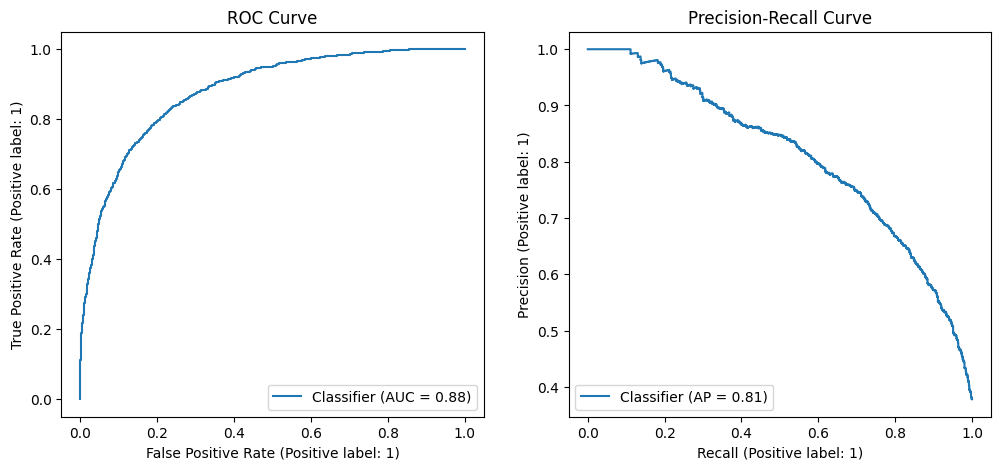


=== LogisticRegression ===
AUROC (95% CI): 0.787 [0.770, 0.805]
AUPRC (95% CI): 0.657 [0.636, 0.677]
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      2145
           1       0.60      0.65      0.62      1113

    accuracy                           0.73      3258
   macro avg       0.70      0.71      0.71      3258
weighted avg       0.74      0.73      0.73      3258

Confusion Matrix:
 [[1653  492]
 [ 385  728]]


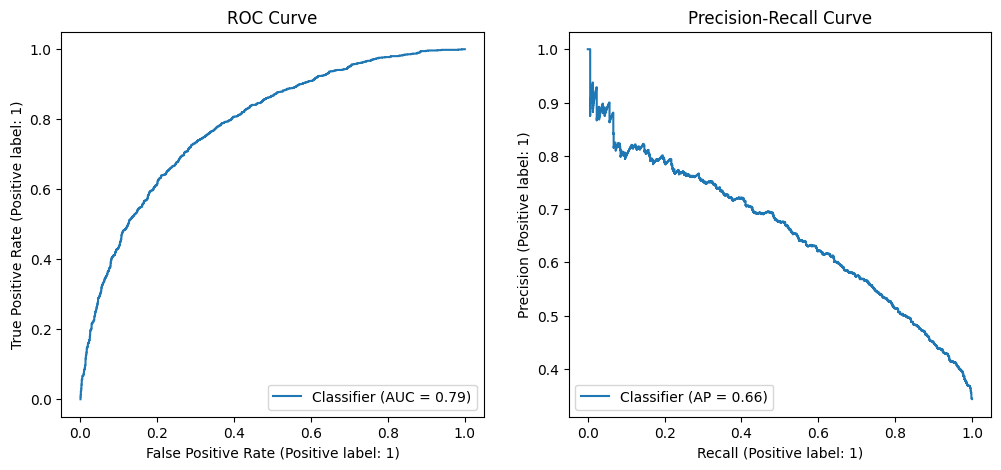


=== RandomForest ===
AUROC (95% CI): 0.840 [0.824, 0.855]
AUPRC (95% CI): 0.740 [0.722, 0.759]
              precision    recall  f1-score   support

           0       0.78      0.93      0.84      2145
           1       0.77      0.48      0.59      1113

    accuracy                           0.77      3258
   macro avg       0.77      0.70      0.72      3258
weighted avg       0.77      0.77      0.76      3258

Confusion Matrix:
 [[1987  158]
 [ 576  537]]


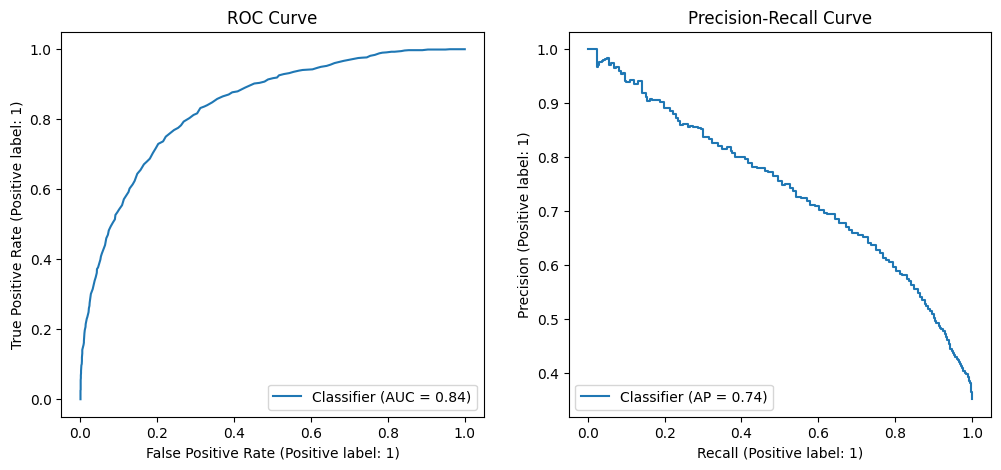


=== MLP ===
AUROC (95% CI): 0.816 [0.799, 0.832]
AUPRC (95% CI): 0.693 [0.673, 0.713]
              precision    recall  f1-score   support

           0       0.82      0.83      0.82      2145
           1       0.66      0.64      0.65      1113

    accuracy                           0.76      3258
   macro avg       0.74      0.73      0.74      3258
weighted avg       0.76      0.76      0.76      3258

Confusion Matrix:
 [[1776  369]
 [ 400  713]]


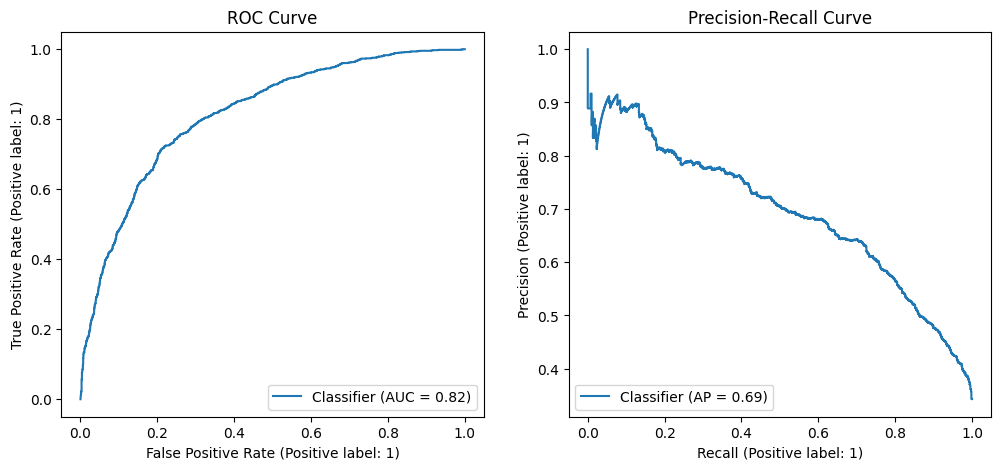


=== SVM ===
AUROC (95% CI): 0.771 [0.753, 0.789]
AUPRC (95% CI): 0.637 [0.616, 0.657]
              precision    recall  f1-score   support

           0       0.76      0.88      0.81      2145
           1       0.66      0.46      0.54      1113

    accuracy                           0.73      3258
   macro avg       0.71      0.67      0.68      3258
weighted avg       0.72      0.73      0.72      3258

Confusion Matrix:
 [[1884  261]
 [ 606  507]]


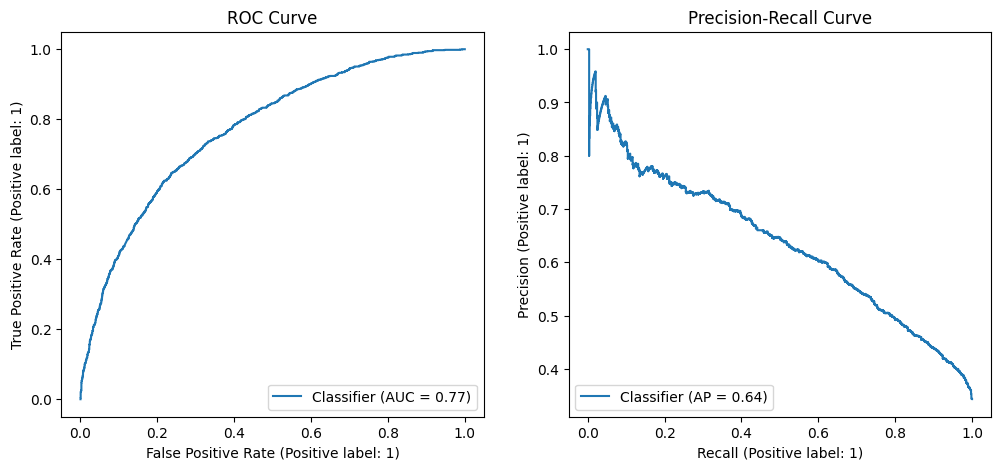

In [5]:
results_summary = []
pred_proba_dict = {}

for name, model in models.items():
    print(f"\n=== {name} ===")

    if name == "XGBoost":
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=0
        )
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    elif name in ["LogisticRegression", "MLP", "SVM", "RandomForest"]:
        model.fit(X_train_scaled, y_train)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    else:
        raise ValueError(f"지원하지 않는 모델: {name}")

    # 평가
    results = evaluate_model(y_test, y_pred_proba, threshold=0.5)
    plot_curves(y_test, y_pred_proba)

    # 저장
    pred_proba_dict[name] = y_pred_proba   # ← 여기 저장
    results_summary.append({
        "Model": name,
        "AUROC": results["auroc"][0],
        "AUROC_CI": results["auroc"][1],
        "AUPRC": results["auprc"][0],
        "AUPRC_CI": results["auprc"][1]
    })


## CNN 1D

2025-09-23 08:09:01.423013: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-23 08:09:01.897045: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22401 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:3b:00.0, compute capability: 8.6
2025-09-23 08:09:01.897673: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22416 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:86:00.0, compute capability: 8.6
2025-09-23 08:09:02.995798: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8907
2025-09-23 08:09:04

AUROC (95% CI): 0.812 [0.795, 0.828]
AUPRC (95% CI): 0.677 [0.657, 0.697]
              precision    recall  f1-score   support

           0       0.78      0.85      0.81      2145
           1       0.65      0.54      0.59      1113

    accuracy                           0.74      3258
   macro avg       0.71      0.69      0.70      3258
weighted avg       0.74      0.74      0.74      3258

Confusion Matrix:
 [[1823  322]
 [ 516  597]]


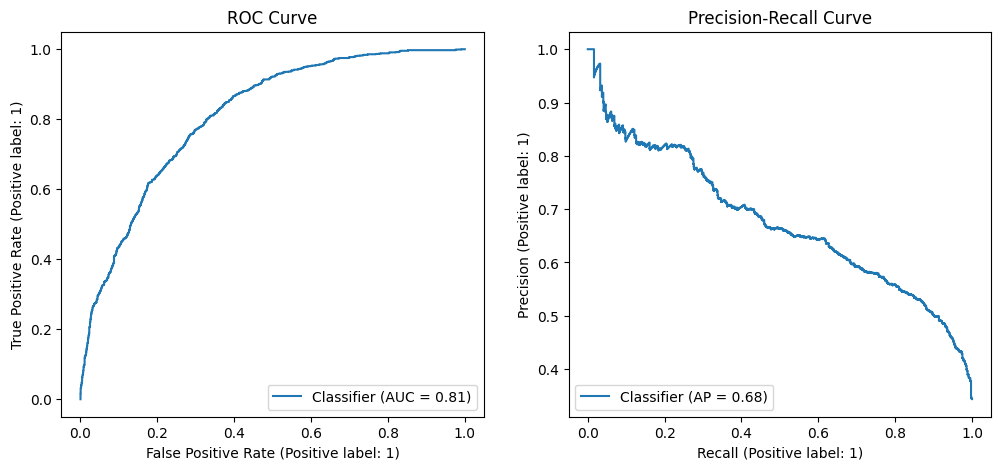

In [6]:
model_cnn1d = keras.models.load_model("../models/cnn1d_best.h5")
y_pred_proba_1d = model_cnn1d.predict(X_test_1d[..., None]).ravel()
results_cnn1d = evaluate_model(y_test, y_pred_proba_1d)
plot_curves(y_test, y_pred_proba_1d)

## CNN 2D

AUROC (95% CI): 0.806 [0.789, 0.823]
AUPRC (95% CI): 0.686 [0.666, 0.706]
              precision    recall  f1-score   support

           0       0.76      0.89      0.82      2145
           1       0.69      0.47      0.56      1113

    accuracy                           0.75      3258
   macro avg       0.73      0.68      0.69      3258
weighted avg       0.74      0.75      0.73      3258

Confusion Matrix:
 [[1903  242]
 [ 585  528]]


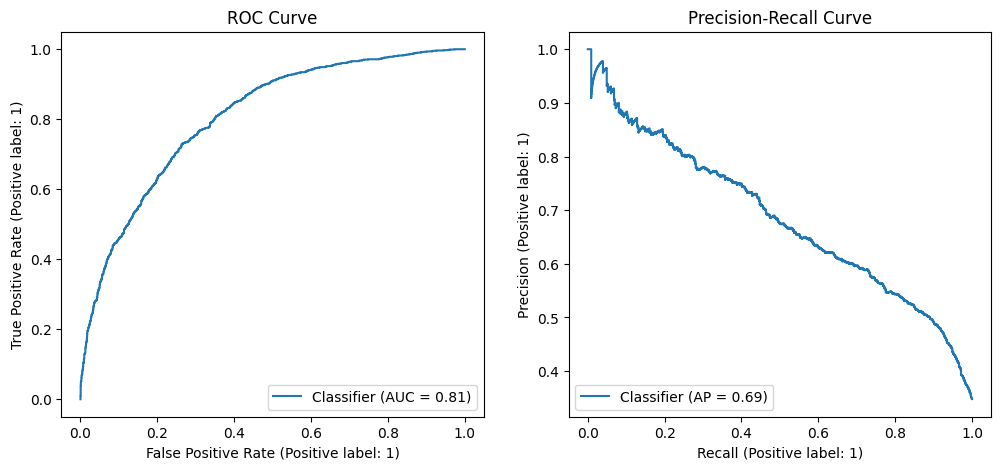

In [7]:
model_cnn2d = keras.models.load_model("../models/cnn2d_best.h5")
y_pred_proba_2d = model_cnn2d.predict(X_test_2d).ravel()
results_cnn2d = evaluate_model(y_test_2d, y_pred_proba_2d)
plot_curves(y_test_2d, y_pred_proba_2d)

# AUROC Curve

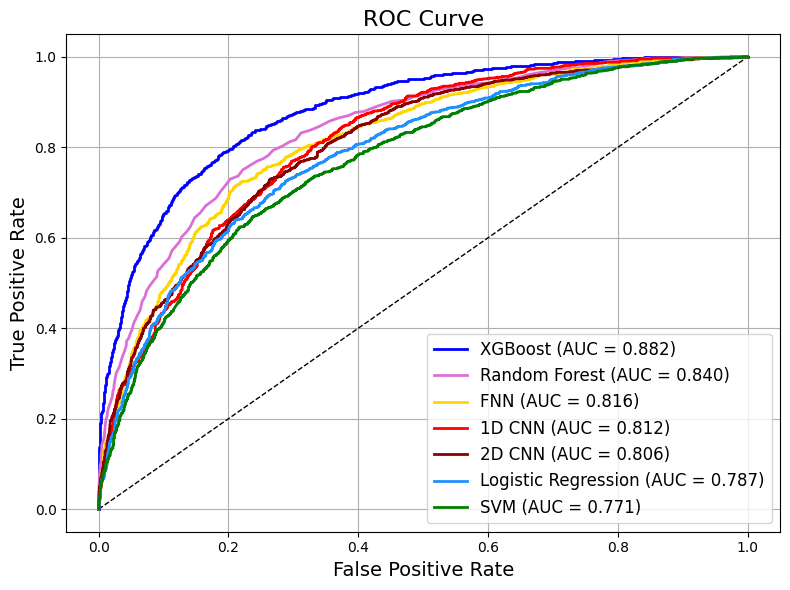

In [8]:
# 여러 모델 결과를 dictionary로 관리
model_results = {
    "XGBoost": (y_test, pred_proba_dict["XGBoost"], "blue"),
    "Random Forest": (y_test, pred_proba_dict["RandomForest"], "orchid"),
    "Logistic Regression": (y_test, pred_proba_dict["LogisticRegression"], "dodgerblue"),
    "FNN": (y_test, pred_proba_dict["MLP"], "gold"),
    "SVM": (y_test, pred_proba_dict["SVM"], "green"),
    "1D CNN": (y_test, y_pred_proba_1d, "red"),
    "2D CNN": (y_test_2d, y_pred_proba_2d, "darkred"),
}


# ROC curve 데이터 계산
roc_data = []
for name, (y_true, y_score, color) in model_results.items():
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_score = roc_auc_score(y_true, y_score)
    roc_data.append((name, auc_score, fpr, tpr, color))

# AUC 기준 정렬
roc_data_sorted = sorted(roc_data, key=lambda x: x[1], reverse=True)

# Plot
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)

for name, auc_score, fpr, tpr, color in roc_data_sorted:
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})",
             linewidth=2, color=color)

plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve", fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Feature Analysis

/home/taejoon/mount_ssd2/2023/scRNA/venv_scrna/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [08:09:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[0]	validation_0-auc:0.73121
[1]	validation_0-auc:0.76460
[2]	validation_0-auc:0.77896
[3]	validation_0-auc:0.78378
[4]	validation_0-auc:0.78860
[5]	validation_0-auc:0.79515
[6]	validation_0-auc:0.79948
[7]	validation_0-auc:0.80046
[8]	validation_0-auc:0.80291
[9]	validation_0-auc:0.80529
[10]	validation_0-auc:0.80570
[11]	validation_0-auc:0.80724
[12]	validation_0-auc:0.81054
[13]	validation_0-auc:0.81238
[14]	validation_0-auc:0.81431
[15]	validation_0-auc:0.81688
[16]	validation_0-auc:0.81788
[17]	validation_0-auc:0.82008
[18]	validation_0-auc:0.82134
[19]	validation_0-auc:0.82277
[20]	validation_0-auc:0.82459
[21]	validation_0-auc:0.82568
[22]	validation_0-auc:0.82789
[23]	validation_0-auc:0.82976
[24]	validation_0-auc:0.83067
[25]	validation_0-auc:0.83220
[26]	validation_0-auc:0.83266
[27]	validation_0-auc:0.83363
[28]	validation_0-auc:0.83462
[29]	validation_0-auc:0.83633
[30]	validation_0-auc:0.83716
[31]	validation_0-auc:0.83830
[32]	validation_0-auc:0.83927
[33]	validation_0-au

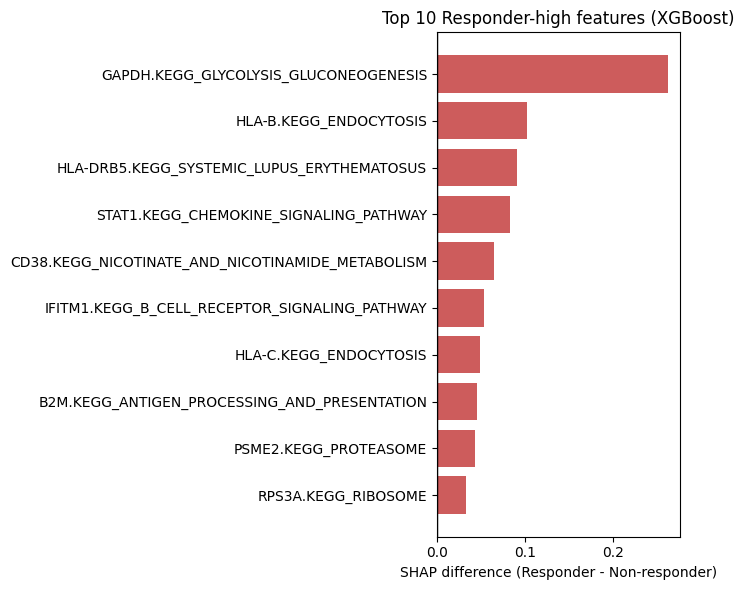

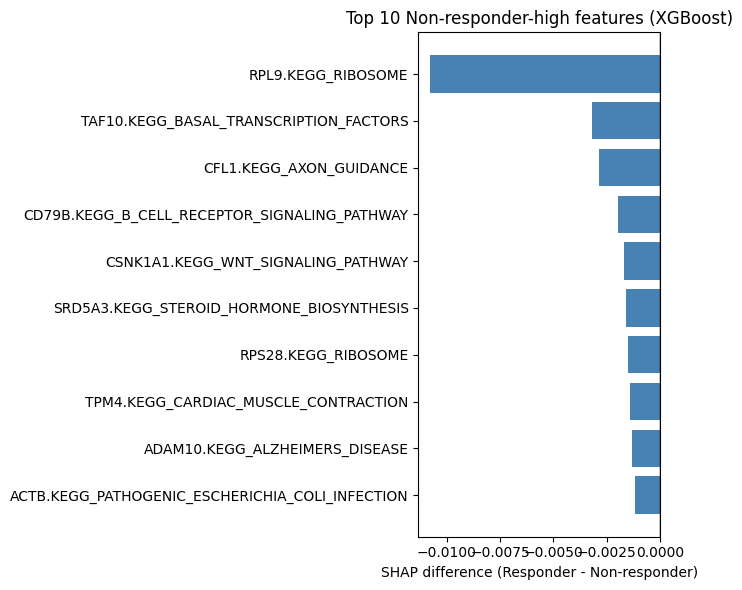

In [9]:
# XGBoost 
model_xgb = models["XGBoost"]
model_xgb.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],   
    verbose=True
)

# SHAP 값 계산
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test_scaled)  # shape = (n_samples, n_features)

# responder / non-responder 분리
responder_idx = np.where(y_test == 1)[0]
nonresponder_idx = np.where(y_test == 0)[0]

shap_responder = shap_values[responder_idx].mean(axis=0)
shap_nonresponder = shap_values[nonresponder_idx].mean(axis=0)

# 그룹 간 차이
shap_diff = shap_responder - shap_nonresponder
shap_df = pd.DataFrame({
    "feature": X.columns,
    "shap_responder": shap_responder,
    "shap_nonresponder": shap_nonresponder,
    "shap_diff": shap_diff
}).sort_values(by="shap_diff", key=abs, ascending=False)

topN = 10

shap_top_pos = shap_df[shap_df["shap_diff"] > 0].nlargest(topN, "shap_diff")
shap_top_neg = shap_df[shap_df["shap_diff"] < 0].nsmallest(topN, "shap_diff")

# Responder-high (양수, 빨강)
plt.figure(figsize=(7, 6))
plt.barh(shap_top_pos["feature"], shap_top_pos["shap_diff"], color="indianred")
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("SHAP difference (Responder - Non-responder)")
plt.title(f"Top {topN} Responder-high features (XGBoost)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Non-responder-high (음수, 파랑)
plt.figure(figsize=(7, 6))
plt.barh(shap_top_neg["feature"], shap_top_neg["shap_diff"], color="steelblue")
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("SHAP difference (Responder - Non-responder)")
plt.title(f"Top {topN} Non-responder-high features (XGBoost)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

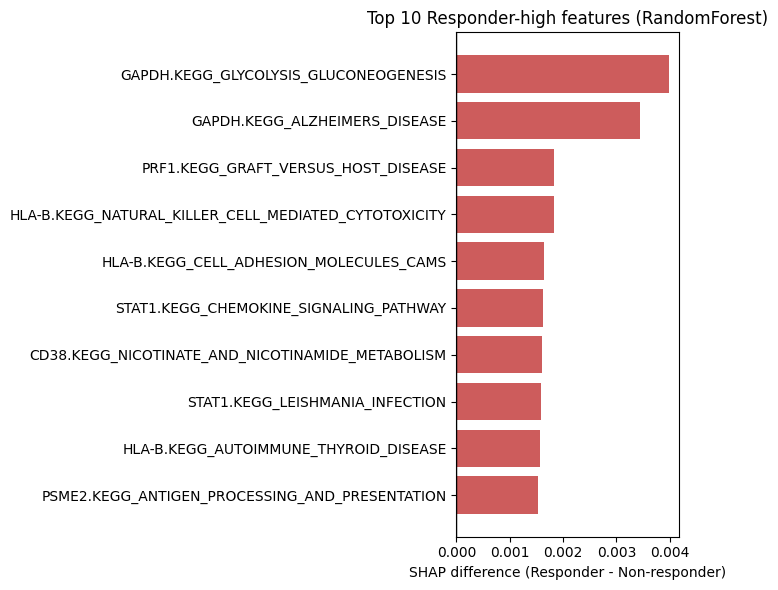

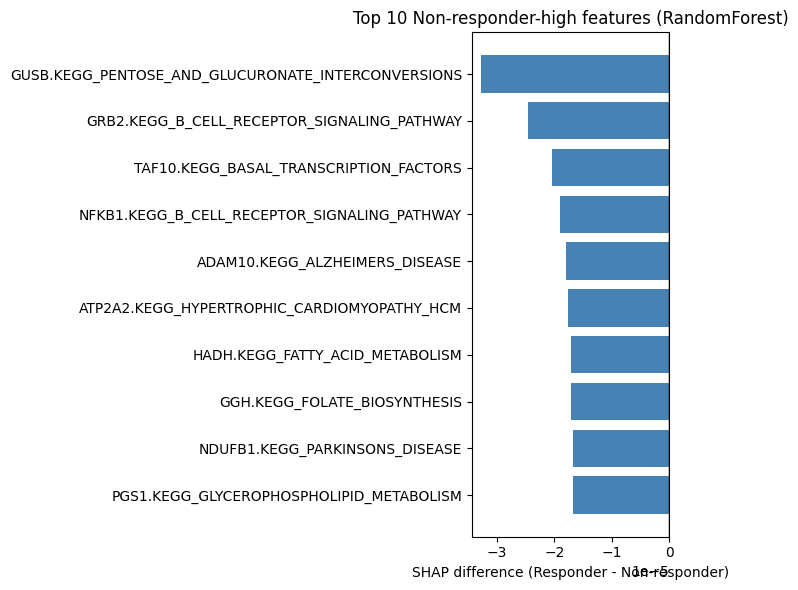

In [10]:
model_rf = models["RandomForest"]
model_rf.fit(X_train_scaled, y_train)

# SHAP 값 계산 (binary classification → class 1만 사용)
explainer_rf = shap.TreeExplainer(model_rf)
shap_values_rf = explainer_rf.shap_values(X_test_scaled, check_additivity=False)
shap_values_rf_class1 = shap_values_rf[:, :, 1]  # positive class (responder 예측)

# 그룹 나누기
responder_idx = (y_test == 1)
nonresponder_idx = (y_test == 0)

# 그룹별 평균 SHAP 값
shap_responder = shap_values_rf_class1[responder_idx].mean(axis=0)
shap_nonresponder = shap_values_rf_class1[nonresponder_idx].mean(axis=0)

# 차이 계산
shap_diff = shap_responder - shap_nonresponder
shap_df = pd.DataFrame({
    "feature": X.columns,
    "shap_diff": shap_diff
})

topN = 10
shap_top_pos = shap_df[shap_df["shap_diff"] > 0].nlargest(topN, "shap_diff")
shap_top_neg = shap_df[shap_df["shap_diff"] < 0].nsmallest(topN, "shap_diff")

# Responder-high (양수 → 빨강)
plt.figure(figsize=(7, 6))
plt.barh(shap_top_pos["feature"], shap_top_pos["shap_diff"], color="indianred")
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("SHAP difference (Responder - Non-responder)")
plt.title(f"Top {topN} Responder-high features (RandomForest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Non-responder-high (음수 → 파랑)
plt.figure(figsize=(7, 6))
plt.barh(shap_top_neg["feature"], shap_top_neg["shap_diff"], color="steelblue")
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("SHAP difference (Responder - Non-responder)")
plt.title(f"Top {topN} Non-responder-high features (RandomForest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

                                                feature  saliency_responder  \
4404                CD38.KEGG_CALCIUM_SIGNALING_PATHWAY           -0.006014   
9072                  CALM3.KEGG_OLFACTORY_TRANSDUCTION           -0.005418   
1330                   ACTB.KEGG_DILATED_CARDIOMYOPATHY            0.013410   
2276          SAT1.KEGG_ARGININE_AND_PROLINE_METABOLISM           -0.008998   
3163         GSTK1.KEGG_DRUG_METABOLISM_CYTOCHROME_P450           -0.008611   
4683             STAT1.KEGG_CHEMOKINE_SIGNALING_PATHWAY           -0.008722   
3088  GSTK1.KEGG_METABOLISM_OF_XENOBIOTICS_BY_CYTOCH...           -0.007329   
4506  CXCR4.KEGG_CYTOKINE_CYTOKINE_RECEPTOR_INTERACTION           -0.002689   
7769   ISG15.KEGG_RIG_I_LIKE_RECEPTOR_SIGNALING_PATHWAY           -0.004209   
4684             STAT2.KEGG_CHEMOKINE_SIGNALING_PATHWAY           -0.007274   
5141  GZMA.KEGG_NEUROACTIVE_LIGAND_RECEPTOR_INTERACTION           -0.005792   
7824            CCL5.KEGG_CYTOSOLIC_DNA_SENSING_PATH

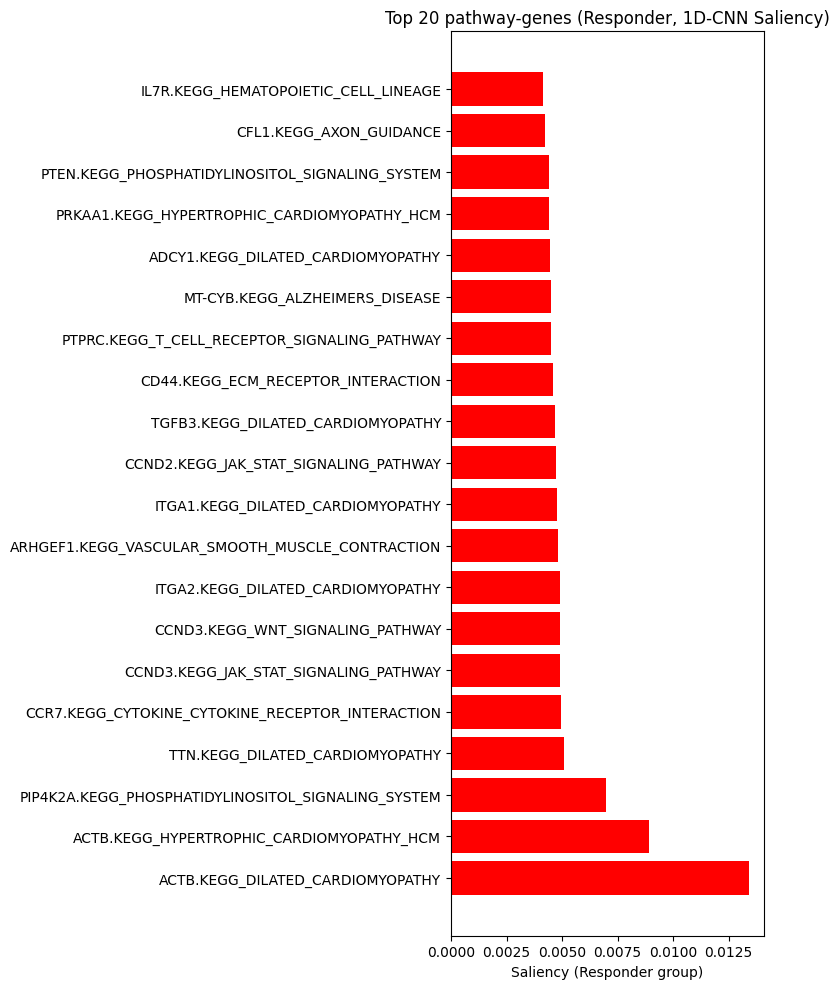

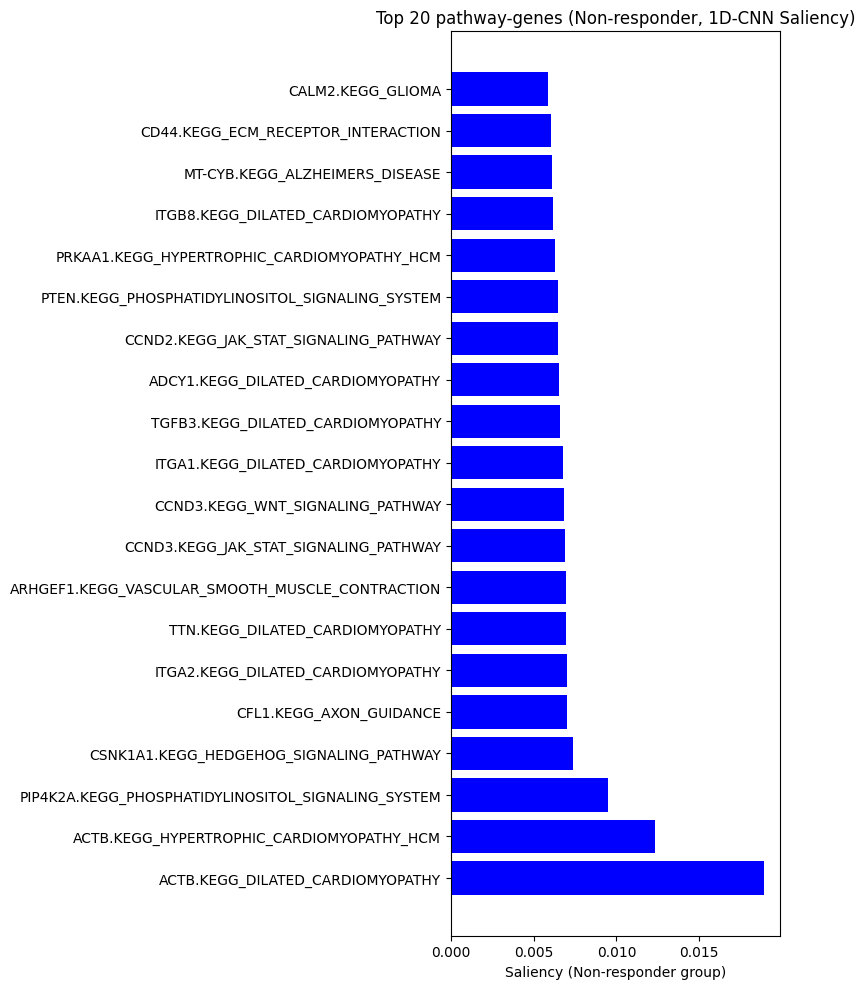

In [16]:
def compute_saliency_batch(model, X, y_class=1, batch_size=32):
    all_saliencies = []
    for i in range(0, len(X), batch_size):
        X_batch = X[i:i+batch_size]
        X_tensor = tf.convert_to_tensor(X_batch, dtype=tf.float32)
        with tf.GradientTape() as tape:
            tape.watch(X_tensor)
            preds = model(X_tensor, training=False)

            # preds shape 확인해서 분기 처리
            if preds.shape[1] == 1:
                score = preds[:, 0]   # binary sigmoid
            else:
                score = preds[:, y_class]  # multi-class softmax

        grads = tape.gradient(score, X_tensor)
        all_saliencies.append(grads.numpy())
    return np.concatenate(all_saliencies, axis=0)


# responder / non-responder 평균 saliency
saliency_responder = compute_saliency_batch(
    model_cnn1d, X_test_1d[y_test==1], batch_size=16
).mean(axis=0).squeeze()
saliency_nonresponder = compute_saliency_batch(
    model_cnn1d, X_test_1d[y_test==0], batch_size=16
).mean(axis=0).squeeze()
saliency_diff = saliency_responder - saliency_nonresponder

# DataFrame으로 정리
saliency_df = pd.DataFrame({
    "feature": X.columns,   # feature 이름
    "saliency_responder": saliency_responder,
    "saliency_nonresponder": saliency_nonresponder,
    "saliency_diff": saliency_diff
}).sort_values(by="saliency_diff", key=np.abs, ascending=False)

print(saliency_df.head(20))

# --- Top 20 responder-high ---
top_n = 20
responder_df = pd.DataFrame({
    "feature": X.columns,
    "saliency": saliency_responder
}).sort_values(by="saliency", ascending=False).head(top_n)

plt.figure(figsize=(8, 10))
plt.barh(responder_df["feature"], responder_df["saliency"], color="red")
plt.xlabel("Saliency (Responder group)")
plt.title(f"Top {top_n} pathway-genes (Responder, 1D-CNN Saliency)")
plt.tight_layout()
plt.show()


# --- Top 20 non-responder-high ---
nonresponder_df = pd.DataFrame({
    "feature": X.columns,
    "saliency": saliency_nonresponder
}).sort_values(by="saliency", ascending=False).head(top_n)

plt.figure(figsize=(8, 10))
plt.barh(nonresponder_df["feature"], nonresponder_df["saliency"], color="blue")
plt.xlabel("Saliency (Non-responder group)")
plt.title(f"Top {top_n} pathway-genes (Non-responder, 1D-CNN Saliency)")
plt.tight_layout()
plt.show()